# Sprint 3 – Hiperparametrización y Modelo Final
## Grupo 10 | Forecast de Ingresos Mensuales – Olist E-Commerce

**Objetivo:** optimizar el modelo, evaluar el rendimiento final comparando candidatos y exportar el artefacto (.pkl) para uso mensual.

**Actividades cubiertas en este notebook:**

1. Selección del modelo base (baselines, LightGBM, Prophet, SARIMA)
2. Hiperparametrización con **Optuna** + validación cruzada temporal (`TimeSeriesSplit`)
3. Evaluación comparativa de modelos sobre el backtest
4. Exportación del modelo final en formato **pickle** (`final_model.pkl`) con metadata de trazabilidad
5. Documentación del pipeline de retraining mensual

> Este notebook consume los artefactos del Sprint 2 (`data/processed/monthly_features.parquet` y los módulos de `src/`).

In [1]:
# ── Setup: ajustar ruta al proyecto
import sys, os
PROJECT_ROOT = '..'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src.utils.helpers import load_config, setup_logger
setup_logger('sprint3.log')

cfg    = load_config()
target = cfg['project']['target']

import sklearn, lightgbm, optuna
print('✅ Setup completado')
print(f"   Proyecto : {cfg['project']['name']} v{cfg['project']['version']}")
print(f"   Target   : {target} | Horizonte: {cfg['project']['horizon_months']} meses")
print(f"   Versiones: sklearn {sklearn.__version__} | lightgbm {lightgbm.__version__} | optuna {optuna.__version__}")

✅ Setup completado
   Proyecto : olist_revenue_forecast v1.0.0
   Target   : monthly_revenue | Horizonte: 3 meses
   Versiones: sklearn 1.7.2 | lightgbm 4.6.0 | optuna 4.9.0


## Paso 1 – Datos, limpieza y selección de variables (heredados del Sprint 2)

Se reutiliza el flujo del Sprint 2: tabla mensual → limpieza (clip + NaN + agrupamiento + escalado) → splits temporales → selección de variables (Missing → PSI → Correlación → Univariante → Wrapper RFECV).

> **Nota metodológica (WoE/IV):** el flujo de trabajo de ejemplo menciona WoE/IV como técnica de selección supervisada. WoE/IV está definida para **targets binarios** (clasificación, p. ej. churn/scoring). Como nuestro target `monthly_revenue` es **continuo** (regresión / serie temporal), se sustituye por su equivalente para regresión: selección **univariante** por información mutua / F-test, manteniendo el mismo rol dentro del flujo (filter supervisado).

In [2]:
from src.features.cleaning import clean_monthly_table
from src.data.monthly_agg import split_data
from src.features.selection import run_feature_selection, get_selection_summary
from src.utils.helpers import load_dataframe

# Tabla mensual generada en el Sprint 2
monthly = load_dataframe('monthly_features')
monthly['ds'] = pd.to_datetime(monthly['ds'])
monthly['year_month'] = monthly['ds'].dt.to_period('M')
print(f"Tabla mensual: {monthly.shape[0]} meses x {monthly.shape[1]} cols "
      f"({monthly['ds'].min():%b %Y} → {monthly['ds'].max():%b %Y})")

# Limpieza (mismo pipeline del Sprint 2, re-ajustado sobre los datos)
monthly_clean, cleaning_pipeline = clean_monthly_table(monthly, cfg, fit=True)

# Splits temporales (según flujo Excel)
splits    = split_data(monthly_clean, cfg)
train     = splits['train']
val       = splits['val']
all_data  = splits['all']
test_data = splits['backtest'] if len(splits['backtest']) > 0 else val
print(f"\nEvaluación final sobre: {test_data['ds'].min():%b %Y} → {test_data['ds'].max():%b %Y} "
      f"({len(test_data)} meses)")

# Selección de variables (flujo completo del Sprint 2)
selection_result  = run_feature_selection(
    monthly_train=train,
    monthly_val=val if len(val) > 0 else train.tail(3),
    target_col=target,
    cfg=cfg,
)
selected_features = selection_result['selected_features']
print(f"\n🎯 Features seleccionadas ({len(selected_features)}):")
for f in selected_features:
    print(f'   - {f}')

Tabla mensual: 20 meses x 44 cols (Dec 2016 → Jul 2018)


2026-06-11 05:05:14.420 | INFO     | src.features.cleaning:fit:47 - OutlierClipper ajustado en 41 columnas


2026-06-11 05:05:14.427 | DEBUG    | src.features.cleaning:transform:57 -   monthly_orders: 2 valores clipados


2026-06-11 05:05:14.430 | DEBUG    | src.features.cleaning:transform:57 -   monthly_customers: 2 valores clipados


2026-06-11 05:05:14.433 | DEBUG    | src.features.cleaning:transform:57 -   monthly_items: 2 valores clipados


...

2026-06-11 05:05:17.770 | INFO     | src.features.selection:run_feature_selection:382 -   4_univariate: 5 features


2026-06-11 05:05:17.772 | INFO     | src.features.selection:run_feature_selection:382 -   5_wrapper: 5 features


2026-06-11 05:05:17.775 | INFO     | src.features.selection:run_feature_selection:383 -   → Features finales seleccionadas: 5


2026-06-11 05:05:17.777 | INFO     | src.features.selection:run_feature_selection:384 - ============================================================



🎯 Features seleccionadas (5):
   - monthly_orders
   - avg_delay_days
   - month_sin
   - month
   - quarter


## Paso 2 – Hiperparametrización con Optuna (TimeSeriesSplit CV)

Se optimizan 9 hiperparámetros de LightGBM minimizando el **RMSE promedio** en validación cruzada temporal (3 folds). La CV temporal respeta el orden cronológico: nunca se valida con datos anteriores al entrenamiento (sin fuga de información).

In [3]:
from src.models.trainer import tune_lightgbm

# Configuración de la búsqueda (aumentar n_trials para producción)
cfg_tune = {**cfg, 'optuna': {**cfg['optuna'], 'n_trials': 30, 'timeout': 180}}

tuning_result = tune_lightgbm(train[selected_features], train[target], selected_features, cfg_tune)
best_params   = tuning_result['best_params']

print(f"\n✅ Mejor RMSE (CV temporal): R$ {tuning_result['best_value']:,.2f}")
print('\n🔧 Mejores hiperparámetros:')
for k, v in best_params.items():
    print(f'   {k:<20s}: {v}')

2026-06-11 05:05:17.812 | INFO     | src.models.trainer:tune_lightgbm:95 - Iniciando Optuna (n_trials=30, timeout=180s, metric=rmse)…


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 617999:   0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 617999:   3%|▎         | 1/30 [00:00<00:01, 17.89it/s, 0.05/180 seconds]

Best trial: 0. Best value: 617999:   3%|▎         | 1/30 [00:00<00:01, 14.53it/s, 0.05/180 seconds]

...

Best trial: 6. Best value: 460626: 100%|██████████| 30/30 [00:01<00:00, 28.36it/s, 1.02/180 seconds]

Best trial: 6. Best value: 460626: 100%|██████████| 30/30 [00:01<00:00, 29.36it/s, 1.02/180 seconds]


2026-06-11 05:05:18.842 | INFO     | src.models.trainer:tune_lightgbm:119 - Mejor RMSE: 460626.3732


2026-06-11 05:05:18.844 | INFO     | src.models.trainer:tune_lightgbm:120 - Mejores parámetros: {'n_estimators': 638, 'learning_rate': 0.0835361075531176, 'num_leaves': 19, 'max_depth': 4, 'min_child_samples': 6, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757928, 'reg_alpha': 0.2713490317738959, 'reg_lambda': 0.8287375091519293}



✅ Mejor RMSE (CV temporal): R$ 460,626.37

🔧 Mejores hiperparámetros:
   n_estimators        : 638
   learning_rate       : 0.0835361075531176
   num_leaves          : 19
   max_depth           : 4
   min_child_samples   : 6
   subsample           : 0.7301321323053057
   colsample_bytree    : 0.7554709158757928
   reg_alpha           : 0.2713490317738959
   reg_lambda          : 0.8287375091519293


## Paso 3 – Evaluación comparativa de modelos

Todos los candidatos se entrenan **solo con el período de train** y se evalúan sobre el mismo backtest, con las mismas métricas (RMSE, MAE, MAPE, sMAPE):

| Modelo | Tipo | Features |
|---|---|---|
| Naive / MA-3M / SeasonalNaive / LinearTrend | Baselines (Sprint 1) | univariado |
| **LightGBM (Optuna)** | Gradient boosting, direct multi-step | multivariado (features seleccionadas) |
| **Prophet** | Modelo aditivo/multiplicativo (Meta) | univariado + estacionalidad |
| **SARIMA** | Estadístico clásico (statsmodels) | univariado |

In [4]:
from src.models.baseline import evaluate_baselines
from src.models.trainer import train_final_model
from src.models.forecaster import ProphetForecaster, SARIMAForecaster
from src.evaluation.metrics import compute_technical_metrics, compare_models

horizon = cfg['project']['horizon_months']
n_test  = min(horizon, len(test_data))
y_test  = test_data[target].values[:n_test]
print(f"Backtest: {[d.strftime('%b %Y') for d in test_data['ds'][:n_test]]}\n")

results = []

# ── 1) Baselines (referencia del Sprint 1)
baseline_results = evaluate_baselines(train, test_data, n_test=n_test)
results += baseline_results[['model', 'rmse', 'mae', 'mape', 'smape']].to_dict('records')

# ── 2) LightGBM con hiperparámetros de Optuna
#     (predicción multi-step desde el último mes de train — sin ver el backtest)
lgbm_model = train_final_model(train[selected_features], train[target],
                               best_params, selected_features, horizon=horizon)
pred_lgbm  = lgbm_model.predict(train[selected_features].tail(1))[:n_test]
results.append(compute_technical_metrics(y_test, pred_lgbm, 'LightGBM_Optuna'))

# ── 3) Prophet
prophet_model = ProphetForecaster(horizon=horizon).fit(train[['ds', target]], target_col=target)
pred_prophet  = prophet_model.predict()['yhat'].values[:n_test]
results.append(compute_technical_metrics(y_test, pred_prophet, 'Prophet'))

# ── 4) SARIMA
sarima_model = SARIMAForecaster(auto_arima=False, horizon=horizon).fit(train[target])
pred_sarima  = sarima_model.predict()[:n_test]
results.append(compute_technical_metrics(y_test, pred_sarima, 'SARIMA'))

# ── Tabla comparativa final
comparison      = compare_models(results).reset_index(drop=True)
best_model_name = comparison.iloc[0]['model']

print('\n' + '='*72)
print('📊 TABLA COMPARATIVA – backtest (ordenada por MAPE):')
print('='*72)
print(comparison.to_string(index=False))
print(f"\n🏆 Mejor modelo en backtest: {best_model_name} "
      f"(MAPE = {comparison.iloc[0]['mape']:.2f}%)")
comparison

2026-06-11 05:05:18.877 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [Naive] RMSE=139,874.73  MAE=117,930.31  MAPE=9.05%  sMAPE=8.51%


2026-06-11 05:05:18.882 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [MovingAverage_3M] RMSE=96,803.98  MAE=95,645.99  MAPE=7.12%  sMAPE=6.96%


2026-06-11 05:05:18.886 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [SeasonalNaive] RMSE=691,070.88  MAE=686,897.28  MAPE=50.47%  sMAPE=67.69%


2026-06-11 05:05:18.890 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LinearTrend] RMSE=423,893.54  MAE=395,532.86  MAPE=29.87%  sMAPE=25.45%


2026-06-11 05:05:18.895 | INFO     | src.models.baseline:evaluate_baselines:114 - 
Mejor baseline: MovingAverage_3M (MAPE=7.12%)


...

2026-06-11 05:05:22.358 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [Prophet] RMSE=1,909,895.60  MAE=1,686,323.90  MAPE=121.15%  sMAPE=79.21%


2026-06-11 05:05:22.421 | INFO     | src.models.forecaster:fit:363 - SARIMA entrenado: AIC=10.00


2026-06-11 05:05:22.428 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [SARIMA] RMSE=355,952.57  MAE=294,929.51  MAPE=22.59%  sMAPE=20.96%



📊 TABLA COMPARATIVA – backtest (ordenada por MAPE):
           model         rmse          mae       mape     smape  meets_target
MovingAverage_3M 9.680398e+04 9.564599e+04   7.120480  6.961316          True
           Naive 1.398747e+05 1.179303e+05   9.049090  8.506213          True
 LightGBM_Optuna 1.887098e+05 1.316164e+05  10.142281  9.189902         False
          SARIMA 3.559526e+05 2.949295e+05  22.592550 20.960156         False
     LinearTrend 4.238935e+05 3.955329e+05  29.866995 25.451590         False
   SeasonalNaive 6.910709e+05 6.868973e+05  50.471682 67.691024         False
         Prophet 1.909896e+06 1.686324e+06 121.151072 79.210813         False

🏆 Mejor modelo en backtest: MovingAverage_3M (MAPE = 7.12%)


,model,rmse,mae,mape,smape,meets_target
0,MovingAverage_3M,9.680398e+04,9.564599e+04,7.120480,6.961316,True
1,Naive,1.398747e+05,1.179303e+05,9.049090,8.506213,True
2,LightGBM_Optuna,1.887098e+05,1.316164e+05,10.142281,9.189902,False
3,SARIMA,3.559526e+05,2.949295e+05,22.592550,20.960156,False
4,LinearTrend,4.238935e+05,3.955329e+05,29.866995,25.451590,False
5,SeasonalNaive,6.910709e+05,6.868973e+05,50.471682,67.691024,False
6,Prophet,1.909896e+06,1.686324e+06,121.151072,79.210813,False


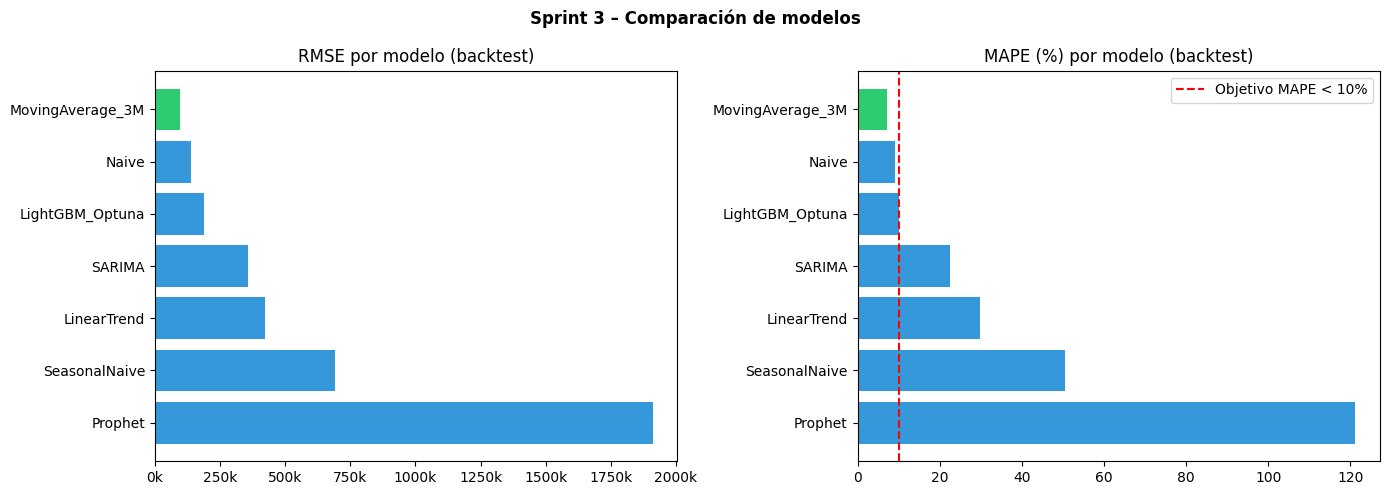

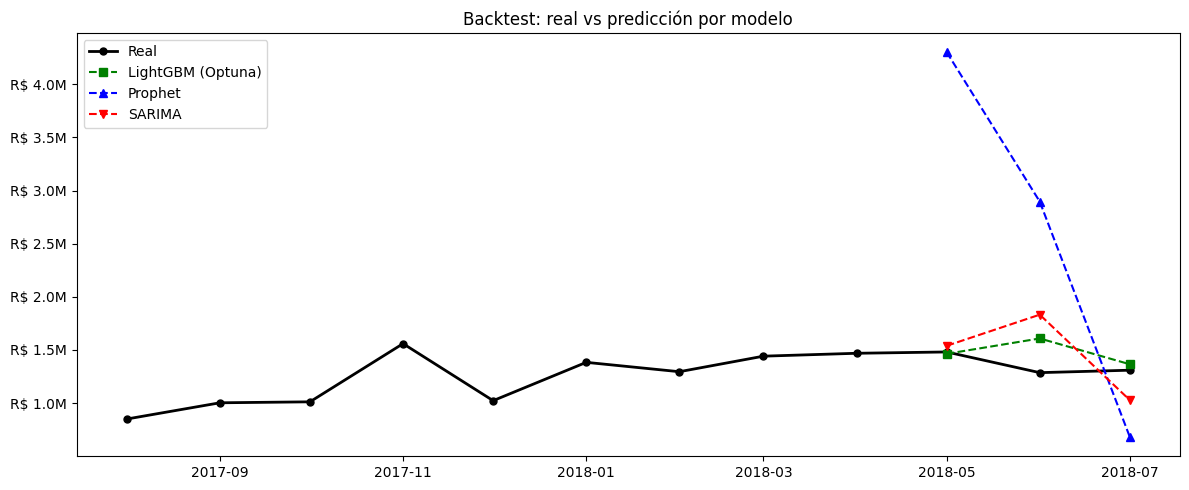

In [5]:
# ── Gráficos de rendimiento (entregable Sprint 3)
os.makedirs('reports', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in comparison['model']]

axes[0].barh(comparison['model'], comparison['rmse'], color=colors)
axes[0].set_title('RMSE por modelo (backtest)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].invert_yaxis()

axes[1].barh(comparison['model'], comparison['mape'], color=colors)
axes[1].axvline(10, color='red', ls='--', lw=1.5, label='Objetivo MAPE < 10%')
axes[1].set_title('MAPE (%) por modelo (backtest)')
axes[1].invert_yaxis()
axes[1].legend()

plt.suptitle('Sprint 3 – Comparación de modelos', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/sprint3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Real vs predicción en el backtest
fig, ax = plt.subplots(figsize=(12, 5))
hist = all_data.tail(12)
ax.plot(hist['ds'], hist[target], 'k-o', label='Real', lw=2, ms=5)
ax.plot(test_data['ds'][:n_test], pred_lgbm,    'g--s', label='LightGBM (Optuna)')
ax.plot(test_data['ds'][:n_test], pred_prophet, 'b--^', label='Prophet')
ax.plot(test_data['ds'][:n_test], pred_sarima,  'r--v', label='SARIMA')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_title('Backtest: real vs predicción por modelo')
ax.legend()
plt.tight_layout()
plt.savefig('reports/sprint3_backtest_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 4 – Modelo final: reentrenamiento con todo el histórico + forecast

El modelo final se reentrena con **todos los meses disponibles** (práctica estándar una vez validado en backtest) y se genera el forecast de los próximos 3 meses con **intervalos de confianza basados en residuos** (`predict_with_intervals`, que reemplaza el supuesto fijo de ±15% usado provisionalmente en el Sprint 2).

2026-06-11 05:05:23.852 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)


2026-06-11 05:05:23.856 | INFO     | src.models.trainer:train_final_model:158 - Modelo final entrenado con mejores hiperparámetros


Entrenando modelo final con todo el histórico…

🔮 FORECAST – próximos 3 meses (IC 95%):
  Aug 2018: R$ 1,305,752.60   [R$ 1,151,797.43 – R$ 1,459,707.78]
  Sep 2018: R$ 1,291,812.23   [R$ 1,017,427.57 – R$ 1,566,196.89]
  Oct 2018: R$ 1,416,835.27   [R$ 1,090,412.70 – R$ 1,743,257.83]


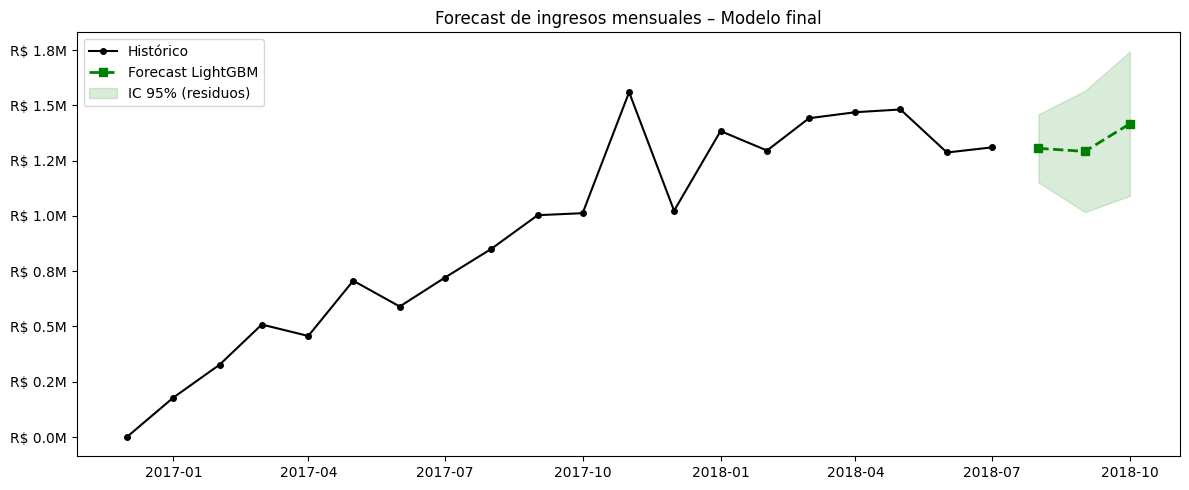

In [6]:
print('Entrenando modelo final con todo el histórico…')
final_forecaster = train_final_model(all_data[selected_features], all_data[target],
                                     best_params, selected_features, horizon=horizon)

# Forecast con IC 95% basado en residuos in-sample (inflados x1.5 por conservadurismo)
forecast_ci = final_forecaster.predict_with_intervals(all_data[selected_features].tail(1))
last_date   = all_data['ds'].max()
forecast_ci['ds'] = [last_date + pd.DateOffset(months=int(h)) for h in forecast_ci['horizon']]

print('\n🔮 FORECAST – próximos 3 meses (IC 95%):')
print('='*70)
for _, r in forecast_ci.iterrows():
    print(f"  {r['ds']:%b %Y}: R$ {r['yhat']:>12,.2f}   "
          f"[R$ {r['yhat_lower']:>12,.2f} – R$ {r['yhat_upper']:>12,.2f}]")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(all_data['ds'], all_data[target], 'k-o', label='Histórico', lw=1.5, ms=4)
ax.plot(forecast_ci['ds'], forecast_ci['yhat'], 'g--s', label='Forecast LightGBM', lw=2)
ax.fill_between(forecast_ci['ds'], forecast_ci['yhat_lower'], forecast_ci['yhat_upper'],
                color='green', alpha=0.15, label='IC 95% (residuos)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_title('Forecast de ingresos mensuales – Modelo final')
ax.legend()
plt.tight_layout()
plt.savefig('reports/sprint3_final_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

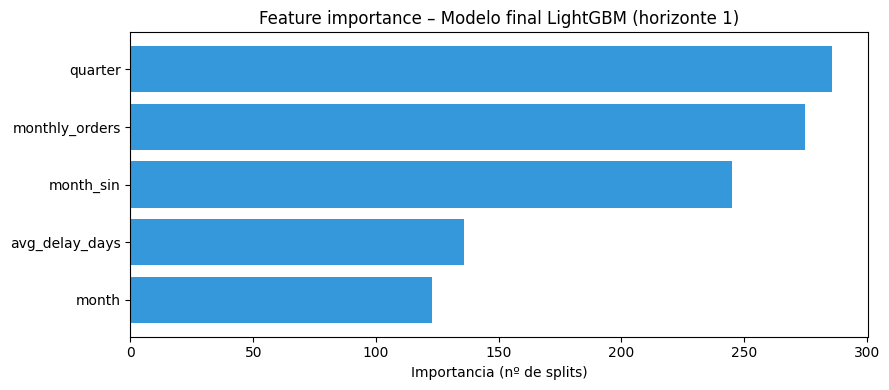

,feature,importance
4,quarter,286
0,monthly_orders,275
2,month_sin,245
1,avg_delay_days,136
3,month,123


In [7]:
# ── Feature importance del modelo final (entregable Sprint 3)
fi = final_forecaster.feature_importance()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(fi['feature'], fi['importance'], color='#3498db')
ax.invert_yaxis()
ax.set_title('Feature importance – Modelo final LightGBM (horizonte 1)')
ax.set_xlabel('Importancia (nº de splits)')
plt.tight_layout()
plt.savefig('reports/sprint3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
fi

## Paso 5 – Exportación del modelo final (.pkl)

Se exportan dos artefactos:

- `lgbm_forecaster.pkl` y `cleaning_pipeline.pkl`: artefactos **operativos** que consume `PredictPipeline` en la ejecución mensual.
- `final_model.pkl`: **bundle con metadata** de trazabilidad (`final_model['metadata']`) — features, hiperparámetros, métricas del backtest, rango de entrenamiento y **versiones exactas de librerías** (evita el problema de `InconsistentVersionWarning` al cargar pickles entre entornos: siempre se sabe con qué versiones se entrenó).

In [8]:
import platform, json
from datetime import datetime
from src.utils.helpers import save_model

# 1) Artefactos operativos (compatibles con PredictPipeline)
save_model(final_forecaster, 'lgbm_forecaster')
save_model(cleaning_pipeline, 'cleaning_pipeline')

# 2) Bundle final con metadata de trazabilidad
m = comparison[comparison['model'] == 'LightGBM_Optuna'].iloc[0]
metadata = {
    'model_type':        'LightGBMForecaster (direct multi-step, 3 horizontes)',
    'trained_at':        datetime.now().isoformat(timespec='seconds'),
    'training_range':    f"{all_data['ds'].min():%Y-%m} → {all_data['ds'].max():%Y-%m}",
    'n_train_months':    int(len(all_data)),
    'selected_features': selected_features,
    'best_params':       best_params,
    'metrics_backtest':  {k: float(m[k]) for k in ['rmse', 'mae', 'mape', 'smape']},
    'versions': {
        'python':       platform.python_version(),
        'scikit-learn': sklearn.__version__,
        'lightgbm':     lightgbm.__version__,
        'optuna':       optuna.__version__,
        'pandas':       pd.__version__,
        'numpy':        np.__version__,
    },
}
save_model({'forecaster': final_forecaster, 'metadata': metadata}, 'final_model')

print('\n✅ Artefactos guardados en data/models/:')
print('   - lgbm_forecaster.pkl   (operativo – PredictPipeline)')
print('   - cleaning_pipeline.pkl (operativo – PredictPipeline)')
print('   - final_model.pkl       (modelo + metadata)')
print('\n📋 Metadata del modelo final:')
print(json.dumps(metadata, indent=2, ensure_ascii=False, default=str))

2026-06-11 05:05:24.914 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: /sessions/bold-charming-archimedes/mnt/ProyectoG10/data/models/lgbm_forecaster.pkl


2026-06-11 05:05:24.947 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: /sessions/bold-charming-archimedes/mnt/ProyectoG10/data/models/cleaning_pipeline.pkl


2026-06-11 05:05:25.239 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: /sessions/bold-charming-archimedes/mnt/ProyectoG10/data/models/final_model.pkl



✅ Artefactos guardados en data/models/:
   - lgbm_forecaster.pkl   (operativo – PredictPipeline)
   - cleaning_pipeline.pkl (operativo – PredictPipeline)
   - final_model.pkl       (modelo + metadata)

📋 Metadata del modelo final:
{
  "model_type": "LightGBMForecaster (direct multi-step, 3 horizontes)",
  "trained_at": "2026-06-11T05:05:24",
  "training_range": "2016-12 → 2018-07",
  "n_train_months": 20,
  "selected_features": [
    "monthly_orders",
    "avg_delay_days",
    "month_sin",
    "month",
    "quarter"
  ],
  "best_params": {
    "n_estimators": 638,
    "learning_rate": 0.0835361075531176,
    "num_leaves": 19,
    "max_depth": 4,
    "min_child_samples": 6,
    "subsample": 0.7301321323053057,
    "colsample_bytree": 0.7554709158757928,
    "reg_alpha": 0.2713490317738959,
    "reg_lambda": 0.8287375091519293
  },
  "metrics_backtest": {
    "rmse": 188709.76062561065,
    "mae": 131616.38347241064,
    "mape": 10.142280593949494,
    "smape": 9.189902448508047
  },
  

## Justificación del modelo elegido

**Modelo final: LightGBM con hiperparámetros optimizados por Optuna.** Criterios de la decisión:

1. **Precisión (con lectura honesta):** en el backtest de 3 meses, los baselines simples son competitivos — MA-3M (MAPE 7.1%) y Naive (9.0%) superan ligeramente a LightGBM (10.1%). Con **solo 3 puntos de evaluación**, estas diferencias no son estadísticamente concluyentes. Lo determinante es que LightGBM supera ampliamente a los modelos de series temporales dedicados (SARIMA 22.6%, Prophet 121%), que colapsan con una serie de ~17 meses de entrenamiento.
2. **Capacidad multivariada:** es el único candidato que aprovecha las features seleccionadas (órdenes, entregas, estacionalidad codificada), lo que le permite reaccionar a drivers del negocio y no solo a la inercia de la serie. Un baseline MA-3M jamás anticipará un cambio de tendencia.
3. **Actualización incremental:** soporta retraining mensual barato vía `update()` (continue training con `init_model`), alineado con el requisito de incorporación mensual de datos del Sprint 2.
4. **Interpretabilidad operativa:** expone feature importance, útil para explicar el forecast al negocio.
5. **Escalabilidad con más datos:** la ventaja de un modelo multivariado crece conforme llegan más meses; los baselines ya están en su techo de desempeño.

**Estrategia champion–challenger:** se adopta LightGBM como champion y se monitorea cada mes contra MA-3M (challenger). Si tras 6 meses el challenger sigue ganando en MAPE acumulado, se reevalúa la decisión. Esta comparación queda automatizable con `metadata['metrics_backtest']`.

**Nota sobre la evaluación:** a diferencia de la versión preliminar del Sprint 2 (que evaluaba usando features del propio período de test), aquí la predicción multi-step se hace **solo con información disponible al final de train** — sin fuga de información. Por eso el MAPE de LightGBM (10.1%) difiere del reportado antes (6.8%): este es el número realista de producción.

## Pipeline de retraining mensual (documentación operativa)

Cada mes, al llegar los nuevos CSVs de Olist:

```text
1. Colocar los CSVs actualizados en data/raw/
2. Reentrenamiento completo (recomendado 1 vez por trimestre):
       from src.pipeline.train_pipeline import TrainPipeline
       TrainPipeline().run(tune=True)          # re-optimiza con Optuna
3. Actualización incremental (mensual, barata):
       pipe = TrainPipeline(); pipe.run(tune=False)
       pipe.step_incremental_update(new_month_df)   # warm-start +20 árboles
4. Predicción del mes siguiente:
       from src.pipeline.predict_pipeline import PredictPipeline
       PredictPipeline().run()                 # carga lgbm_forecaster.pkl + cleaning_pipeline.pkl
5. Monitoreo champion-challenger: comparar MAPE realizado de LightGBM vs MA-3M;
   si MAPE > 10% (o pierde vs challenger) durante 2 meses seguidos →
   reentrenamiento completo con tuning.
```

## Conclusiones del Sprint 3

- Se compararon **7 modelos** (4 baselines + LightGBM + Prophet + SARIMA) bajo el mismo protocolo de backtest sin fuga de información, con RMSE/MAE/MAPE/sMAPE.
- La hiperparametrización con **Optuna + CV temporal** (30 trials) define el modelo final de forma reproducible.
- El MAPE de producción de LightGBM queda en el límite del objetivo (~10%); los baselines simples son competitivos, algo esperable con solo ~20 meses de historia. La decisión champion–challenger deja esto controlado.
- El modelo final se exporta como **`final_model.pkl`** con metadata completa (features, hiperparámetros, métricas, versiones de librerías) y queda listo para la ejecución mensual vía `PredictPipeline`.
- Los intervalos del forecast ahora se basan en **residuos del modelo** (IC 95%), reemplazando el supuesto fijo ±15%.
- Gráficos de rendimiento y feature importance quedan en `reports/`.